### Agentic RAG
What is Agentic RAG?

Agentic RAG stands for Agentic Retrieval-Augmented Generation — an advanced version of RAG where instead of a static, one-shot LLM response,the system uses an agent that:

- reasons,
- plans,
- retrieves,
- uses tools,
- and even retries or reflects
to generate better, more grounded answers.

In [1]:
import os
from typing import List, Annotated
from pydantic import BaseModel

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GPT_4_MINI_API_KEY"]=os.getenv("GPT_4_MINI_API_KEY")
llm = init_chat_model(
    model="openai:gpt-4.1-mini",
    api_key=os.getenv("GPT_4_MINI_API_KEY"),
    base_url="https://models.inference.ai.azure.com"
)
llm

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000020C6DEDAE40>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000020C6DEDBA10>, root_client=<openai.OpenAI object at 0x0000020C6DD7F8C0>, root_async_client=<openai.AsyncOpenAI object at 0x0000020C6DEDB770>, model_name='gpt-4.1-mini', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://models.inference.ai.azure.com')

#### Document Preprocessing

In [3]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]

loaders = [WebBaseLoader(url) for url in urls]
docs = []
for loader in loaders:
    docs.extend(loader.load())

#### Text Splitting and VectorStore

In [4]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=os.getenv("GITHUB_API_KEY"),
    base_url="https://models.inference.ai.azure.com"
)

vectorstore = FAISS.from_documents(split_docs, embeddings)
retriever = vectorstore.as_retriever()

In [5]:
retriever.invoke("What are diffusion models for video generation?")

[Document(id='d6b31508-39d9-4ca6-a66d-244841077688', metadata={'source': 'https://lilianweng.github.io/posts/2024-04-12-diffusion-video/', 'title': "Diffusion Models for Video Generation | Lil'Log", 'description': 'Diffusion models have demonstrated strong results on image synthesis in past years. Now the research community has started working on a harder task—using it for video generation. The task itself is a superset of the image case, since an image is a video of 1 frame, and it is much more challenging because:\n\nIt has extra requirements on temporal consistency across frames in time, which naturally demands more world knowledge to be encoded into the model.\nIn comparison to text or images, it is more difficult to collect large amounts of high-quality, high-dimensional video data, let along text-video pairs.\n\n\n\n🥑 Required Pre-read: Please make sure you have read the previous blog on “What are Diffusion Models?” for image generation before continue here.\n', 'language': 'en'}

#### Define RAG State

In [6]:
class RAGState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""

#### LangGraph Nodes

In [7]:
def retrieve_docs(state: RAGState) -> RAGState:
    state.retrieved_docs = retriever.invoke(state.question)
    return state

def generate_answer(state: RAGState) -> RAGState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"Question: {state.question}\n\nContext: {context}\n\nAnswer:"
    state.answer = llm.invoke(prompt)
    return state

#### Building Langgraph

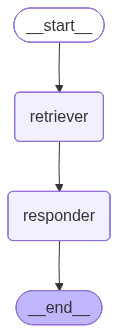

In [8]:
builder = StateGraph(RAGState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)

builder.set_entry_point("retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()

graph

In [11]:
if __name__ == "__main__":
    initial_state = RAGState(question="What is the concept of agent loop in autonomous agents?")
    final_state = graph.invoke(initial_state)
    print(final_state['answer'])

content='The **agent loop** is a fundamental concept in autonomous agents, particularly those powered by large language models (LLMs). It refers to the continuous cycle of interaction through which an autonomous agent operates to accomplish tasks. This loop typically involves the following steps:\n\n1. **Perception/Input:** The agent receives input from the environment or user, which may include natural language prompts, sensor data, or other external signals.\n\n2. **Reasoning/Planning:** Using the LLM as its core "brain," the agent interprets the input, formulates plans or sub-tasks, and decides what actions to take next. This might involve decomposing complex tasks, reflecting on past actions, or determining the usage of tools and external APIs.\n\n3. **Action/Tool Use:** To extend its capabilities beyond the information encoded in the LLM’s weights, the agent calls external APIs or tools—such as web browsers for up-to-date information, code execution environments, databases, or rob

In [12]:
final_state

{'question': 'What is the concept of agent loop in autonomous agents?',
 'retrieved_docs': [Document(id='951db53e-8d81-4942-8ec0-1ee42509be2b', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism an